In [2]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
plt.style.use ('default')

In [71]:
df = pd.read_csv(
    r"C:\Users\ohabi\OneDrive\Desktop\MRLF DATA FELLOW ASSIGNMENTS\sample_meghalaya_constituency_data.csv"
)
df.head()

,Constituency_ID,Constituency_Name,District,Region,Electorate_2023,Voter_Turnout_2023_Pct,Total_Households,BPL_Households_Pct,BPL_Households_Count,MGNREGS_Active_Job_Cards,...,Primary_Health_Centres,Community_Health_Centres,Govt_Primary_Schools,Govt_Secondary_Schools,Literacy_Rate_Pct,PM_KISAN_Beneficiaries,Internet_4G_Coverage_Pct,Constituency_Fund_Allocated_Lakhs,Constituency_Fund_Utilized_Pct,Primary_Occupation
0,MH001,Mawlai,East Khasi Hills,Khasi Hills,39296.0,55.5,5583.0,26.7,1490.0,300.0,...,5.0,0.0,53.0,20.0,87.9,499.0,87.6,133.91,50.1,Trade & Services
1,MH002,Pynthorumkhrah,East Khasi Hills,Khasi Hills,59696.0,61.8,11016.0,18.7,2059.0,234.0,...,1.0,2.0,26.0,22.0,94.4,281.0,83.4,123.40,44.5,Government Employment
2,MH003,Nongthymmai,East Khasi Hills,Khasi Hills,37229.0,72.1,4649.0,21.1,980.0,220.0,...,2.0,2.0,54.0,10.0,84.3,331.0,78.9,125.53,96.3,Trade & Services
3,MH004,Shillong East,East Khasi Hills,Khasi Hills,53252.0,71.9,6493.0,12.6,818.0,120.0,...,6.0,1.0,17.0,11.0,84.0,517.0,73.4,169.40,67.0,Trade & Services
4,MH005,Shillong West,East Khasi Hills,Khasi Hills,58175.0,62.2,6467.0,21.9,1416.0,302.0,...,4.0,2.0,24.0,20.0,94.1,482.0,78.1,81.38,78.8,Government Employment


In [11]:
def benchmark(value, state_mean, region_mean):

    if value > state_mean:
        state_flag = "↑ State"
    elif value < state_mean:
        state_flag = "↓ State"
    else:
        state_flag = "→ State"

    if value > region_mean:
        region_flag = "↑ Region"
    elif value < region_mean:
        region_flag = "↓ Region"
    else:
        region_flag = "→ Region"

    return f"{state_flag} | {region_flag}"

In [12]:
profiles = []

for _, row in df.iterrows():

    region = row['Region']

    profile = {

        # SNAPSHOT
        'Constituency': row['Constituency_Name'],
        'District': row['District'],
        'Region': row['Region'],
        'Electorate': row['Electorate_2023'],
        'Primary Occupation': row['Primary_Occupation'],
        'Literacy Rate (%)': row['Literacy_Rate_Pct'],

        # GOVERNMENT SCHEMES
        'MGNREGS Person Days':
            row['MGNREGS_Person_Days_FY2425'],

        'PM Awas Completion (%)':
            row['PM_Awas_Completion_Pct'],

        'JJM Coverage (%)':
            row['JJM_Functional_Tap_Connections_Pct'],

        'PM KISAN Beneficiaries':
            row['PM_KISAN_Beneficiaries'],

        # INFRASTRUCTURE
        'Road Length (km)':
            row['Road_Length_Km'],

        'Pucca Road (%)':
            row['Pucca_Road_Pct'],

        '4G Coverage (%)':
            row['Internet_4G_Coverage_Pct'],

        'Health Facilities':
            row['Health_Sub_Centres']
            + row['Primary_Health_Centres']
            + row['Community_Health_Centres'],

        'Schools':
            row['Govt_Primary_Schools']
            + row['Govt_Secondary_Schools']
    }

    profiles.append(profile)

profiles_df = pd.DataFrame(profiles)

In [13]:
benchmark_vars = {

    'Literacy Rate (%)':'Literacy_Rate_Pct',
    'MGNREGS Person Days':'MGNREGS_Person_Days_FY2425',
    'PM Awas Completion (%)':'PM_Awas_Completion_Pct',
    'JJM Coverage (%)':'JJM_Functional_Tap_Connections_Pct',
    'PM KISAN Beneficiaries':'PM_KISAN_Beneficiaries',
    'Road Length (km)':'Road_Length_Km',
    'Pucca Road (%)':'Pucca_Road_Pct',
    '4G Coverage (%)':'Internet_4G_Coverage_Pct'
}

for display,col in benchmark_vars.items():

    profiles_df[f'{display} Benchmark'] = df.apply(
        lambda x:
        benchmark(
            x[col],
            state_avg[col],
            regional_avg.loc[x['Region'], col]
        ),
        axis=1
    )

In [14]:
profiles_df['Fund Utilisation Warning'] = np.where(
    df['Constituency_Fund_Utilized_Pct'] < 60,
    "⚠ BELOW 60%",
    "OK"
)

In [15]:
profiles_df.to_excel(
    "Meghalaya_Constituency_Profile_Report.xlsx",
    index=False
)

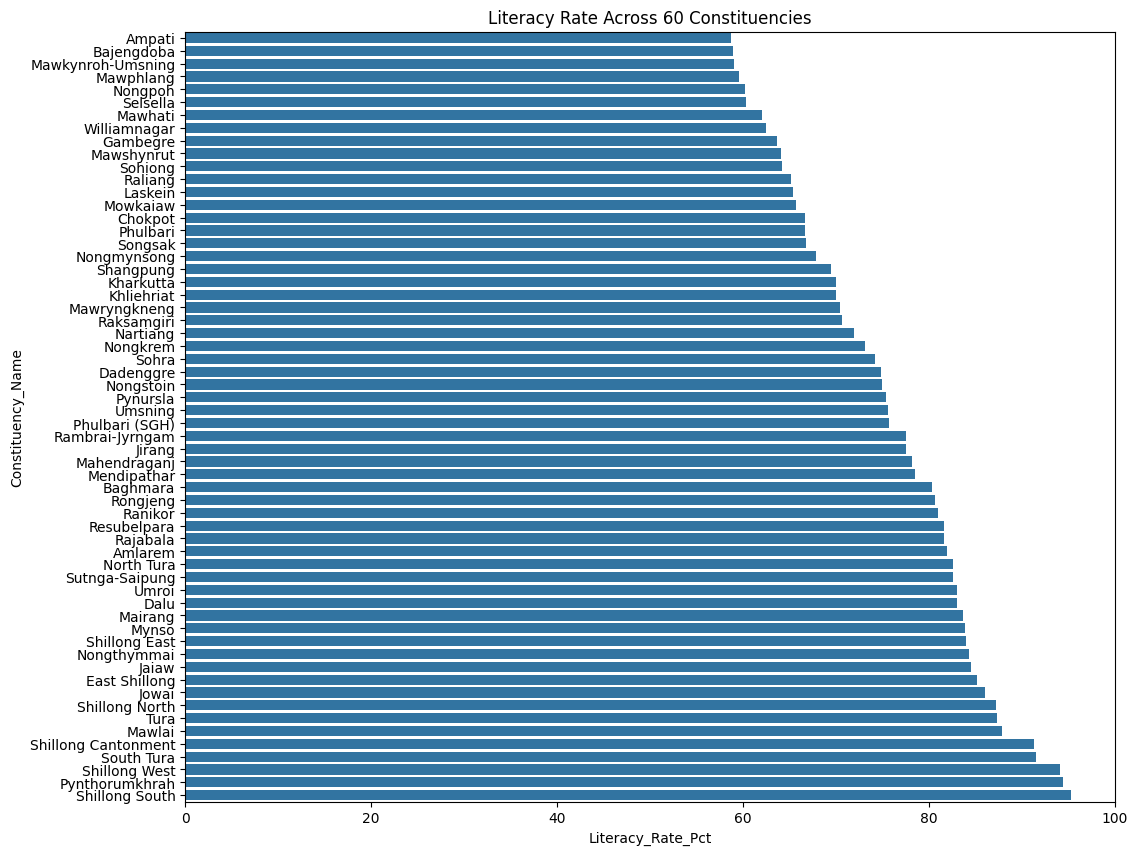

In [34]:
top_bottom = (
    df[['Constituency_Name','Literacy_Rate_Pct']]
    .sort_values('Literacy_Rate_Pct')
)

plt.figure(figsize=(12,10))

sns.barplot(
    data=top_bottom,
    x='Literacy_Rate_Pct',
    y='Constituency_Name'
)

plt.title("Literacy Rate Across 60 Constituencies")
plt.show()

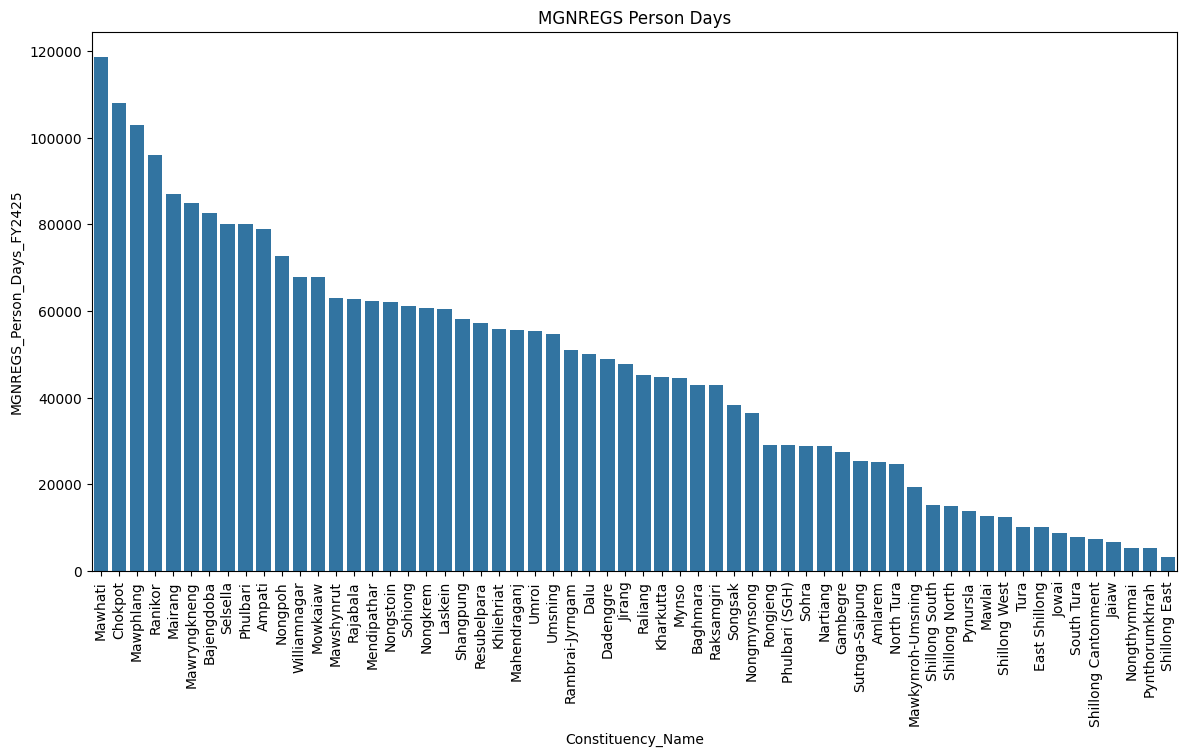

In [17]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=df.sort_values(
        'MGNREGS_Person_Days_FY2425',
        ascending=False
    ),
    x='Constituency_Name',
    y='MGNREGS_Person_Days_FY2425'
)

plt.xticks(rotation=90)

plt.title("MGNREGS Person Days")
plt.show()

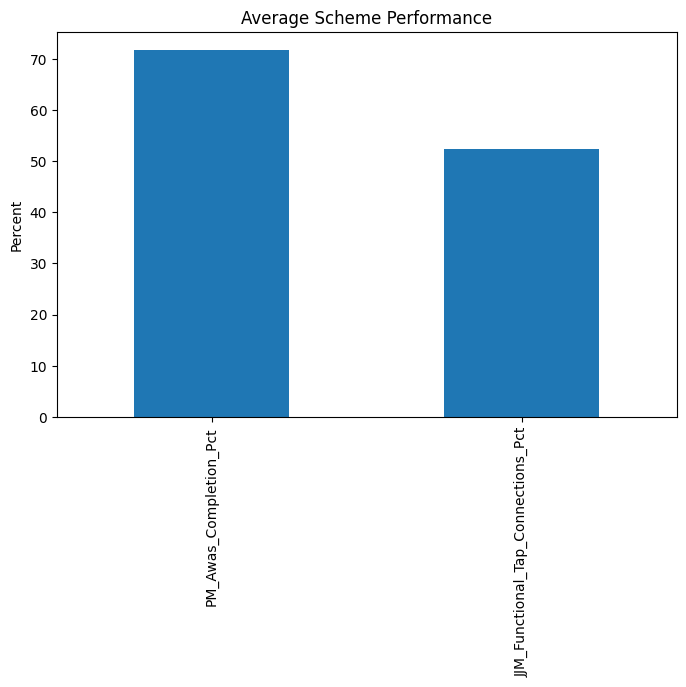

In [28]:
scheme_scores = df[[
    'PM_Awas_Completion_Pct',
    'JJM_Functional_Tap_Connections_Pct'
]].mean()

scheme_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Scheme Performance")
plt.ylabel("Percent")
plt.show()

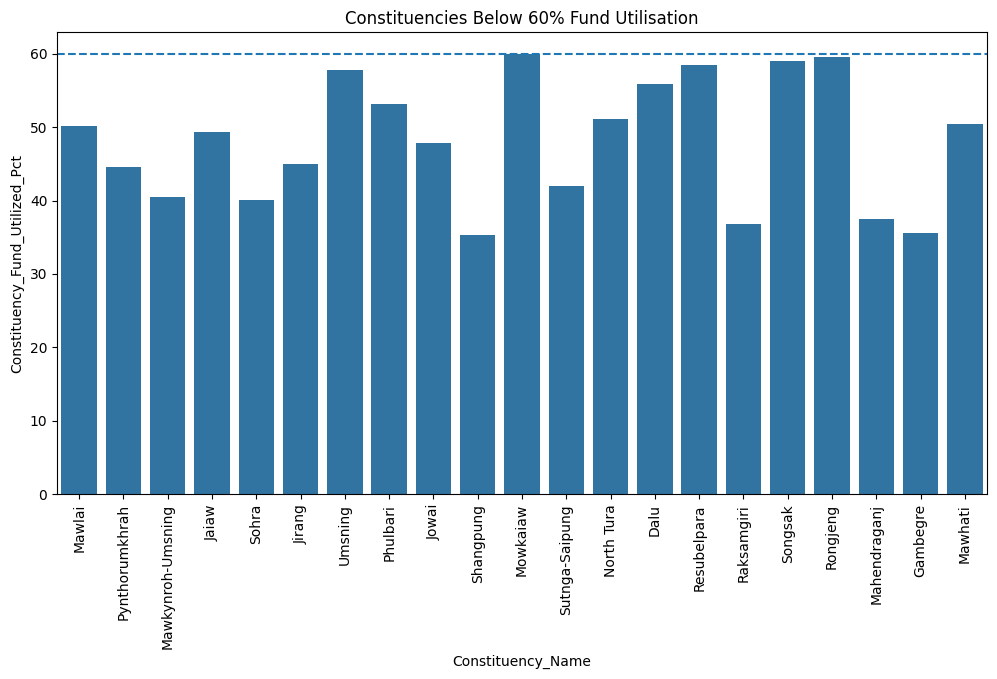

In [33]:
risk = df[
    df['Constituency_Fund_Utilized_Pct'] < 60
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=risk,
    x='Constituency_Name',
    y='Constituency_Fund_Utilized_Pct'
)

plt.xticks(rotation=90)

plt.axhline(
    60,
    linestyle='--'
)

plt.title("Constituencies Below 60% Fund Utilisation")
plt.show()

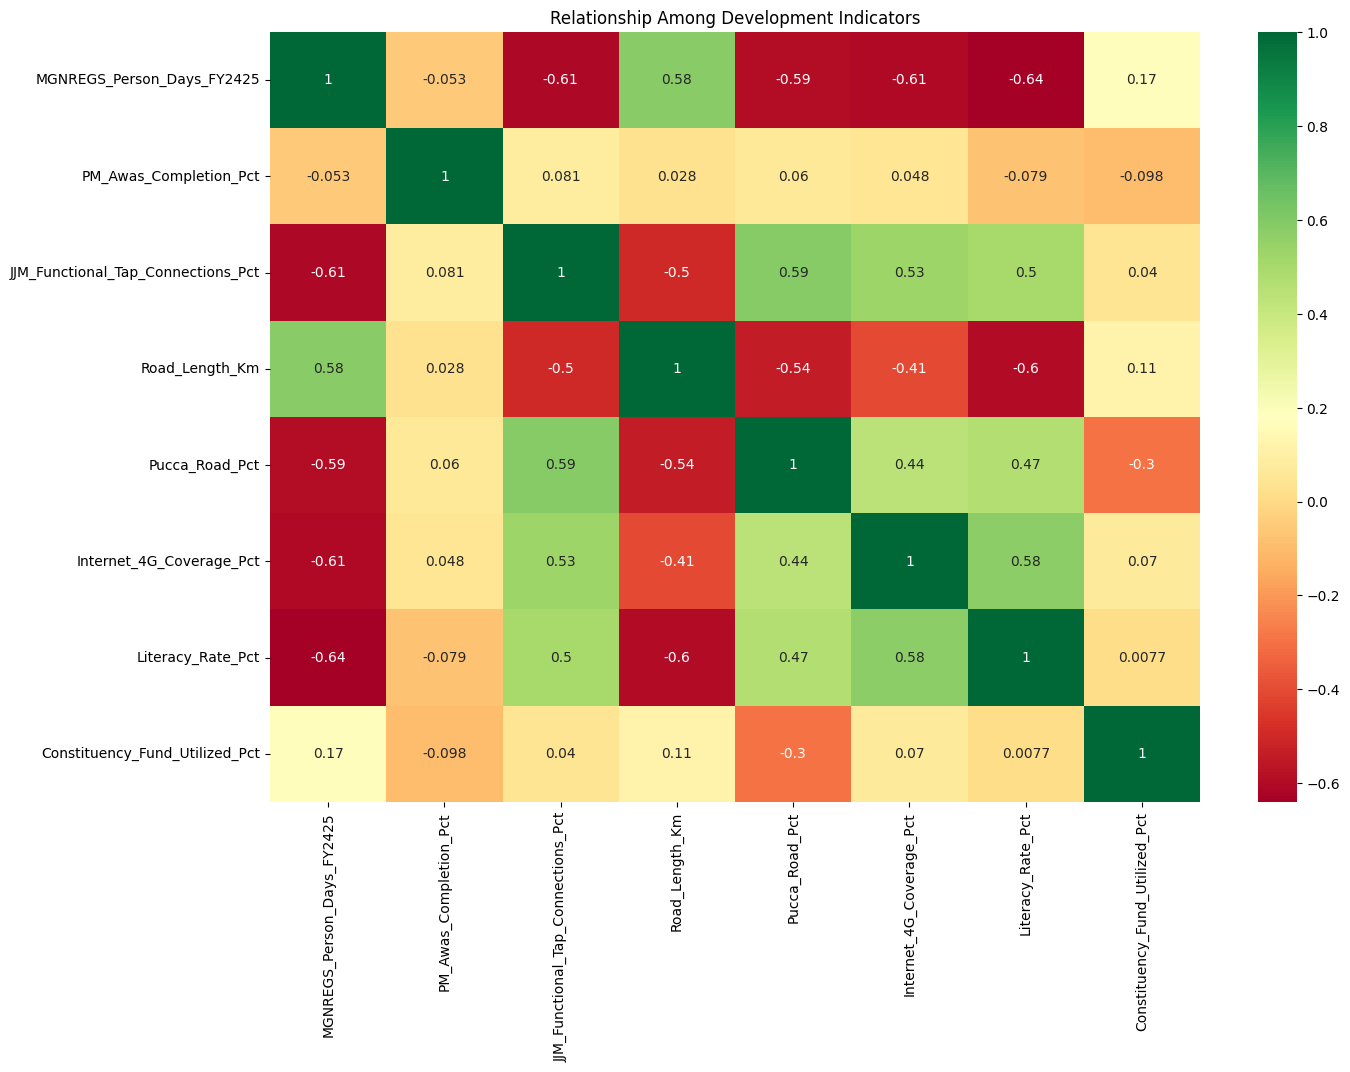

In [31]:
heatmap_data = df[[
    'MGNREGS_Person_Days_FY2425',
    'PM_Awas_Completion_Pct',
    'JJM_Functional_Tap_Connections_Pct',
    'Road_Length_Km',
    'Pucca_Road_Pct',
    'Internet_4G_Coverage_Pct',
    'Literacy_Rate_Pct',
    'Constituency_Fund_Utilized_Pct',

]]

plt.figure(figsize=(15,10))

sns.heatmap(
    heatmap_data.corr(),
    annot=True,
    cmap='RdYlGn'
)

plt.title(
    "Relationship Among Development Indicators"
)

plt.show()

In [35]:
with pd.ExcelWriter(
    "Meghalaya_Constituency_Report.xlsx",
    engine="openpyxl"
) as writer:

    profiles_df.to_excel(
        writer,
        sheet_name="Constituency Profiles",
        index=False
    )

    regional_avg.to_excel(
        writer,
        sheet_name="Regional Averages"
    )

    pd.DataFrame(state_avg).to_excel(
        writer,
        sheet_name="State Averages"
    )

print("Excel Report Exported Successfully")

Excel Report Exported Successfully


In [36]:
benchmark_summary = profiles_df[
    [
        'Constituency',
        'Literacy Rate (%) Benchmark',
        'MGNREGS Person Days Benchmark',
        'PM Awas Completion (%) Benchmark',
        'JJM Coverage (%) Benchmark',
        'Road Length (km) Benchmark',
        '4G Coverage (%) Benchmark',
        'Fund Utilisation Warning'
    ]
]

benchmark_summary.to_excel(
    "Benchmark_Summary.xlsx",
    index=False
)

In [37]:
plt.savefig(
    "literacy_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>

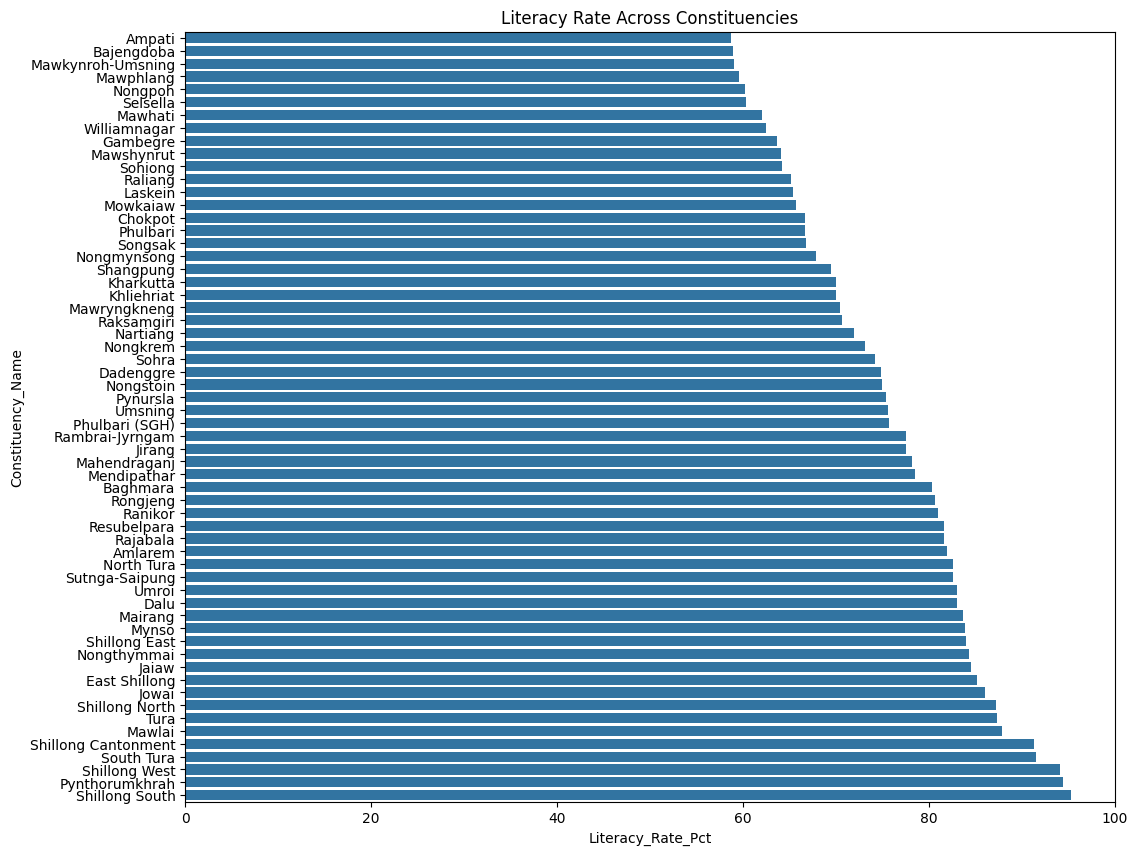

In [39]:
plt.figure(figsize=(12,10))

sns.barplot(
    data=df.sort_values('Literacy_Rate_Pct'),
    x='Literacy_Rate_Pct',
    y='Constituency_Name'
)

plt.title("Literacy Rate Across Constituencies")

plt.savefig(
    "Plot_01_Literacy.png",
    dpi=315,
    bbox_inches='tight'
)

plt.show()

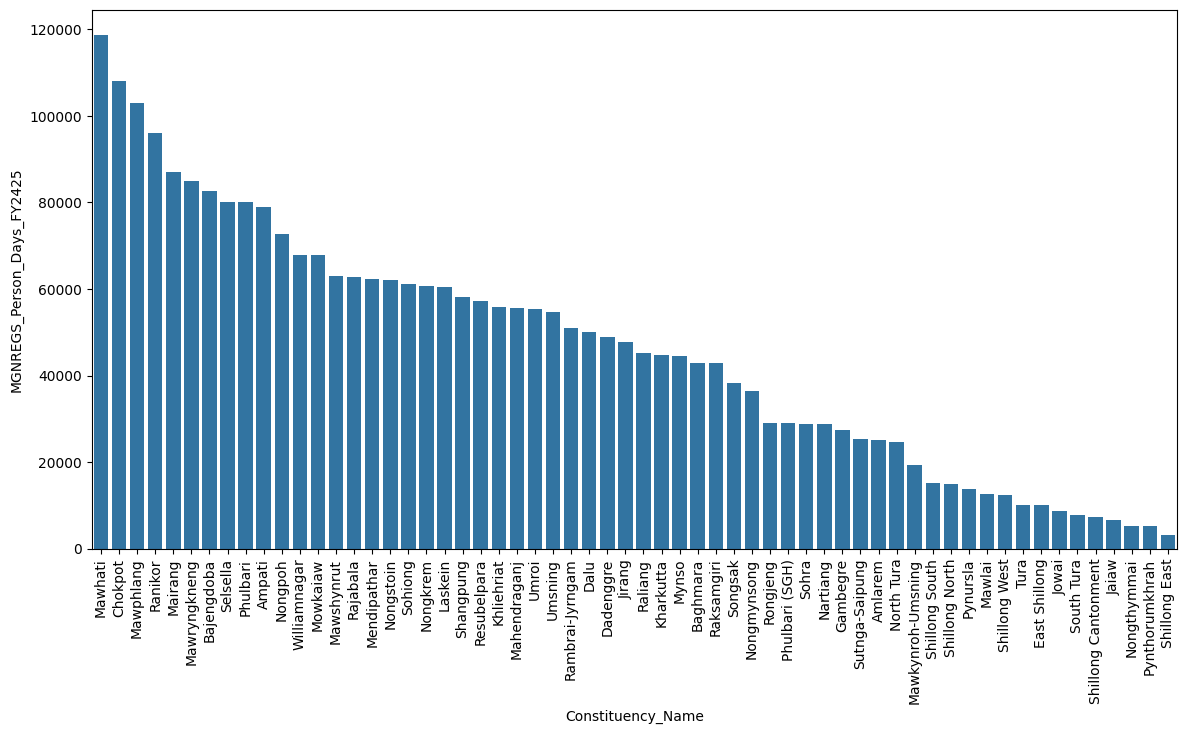

In [40]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=df.sort_values(
        'MGNREGS_Person_Days_FY2425',
        ascending=False
    ),
    x='Constituency_Name',
    y='MGNREGS_Person_Days_FY2425'
)

plt.xticks(rotation=90)

plt.savefig(
    "Plot_02_MGNREGS.png",
    dpi=310,
    bbox_inches='tight'
)

plt.show()

In [41]:
import os

output_folder = "Meghalaya_Report"

os.makedirs(
    output_folder,
    exist_ok=True
)

In [42]:
plt.savefig(
    f"{output_folder}/Plot_01_Literacy.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [43]:
profiles_df.to_excel(
    f"{output_folder}/Constituency_Profiles.xlsx",
    index=False
)

In [63]:
plots = [
    ('Literacy_Rate_Pct','Literacy'),
    ('MGNREGS_Person_Days_FY2425','MGNREGS'),
    ('PM_Awas_Completion_Pct','PM_Awas'),
    ('JJM_Functional_Tap_Connections_Pct','JJM'),
    ('Internet_4G_Coverage_Pct','4G'),
    ('Constituency_Fund_Utilized_Pct','Fund_Utilisation')
]

for var,name in plots:

    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df.sort_values(var),
        x=var,
        y='Constituency_Name'
    )

    plt.title(name)

    plt.savefig(
        f"{output_folder}/{name}.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

print("All plots exported")

All plots exported


In [45]:
pip install python-docx

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.0 MB 3.5 MB/s eta 0:00:01
   ------------- -------------------------- 1.3/4.0 MB 3.3 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.0 MB 3.4 MB/s eta 0:00:01
   ----------------------- ---------------- 2.4/4.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.0 MB 2.7 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.0 MB 2.7 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 2.1 MB/s eta 0:00:01
   ---------------------------------- ----- 3.4/4.0 MB 1.6 MB/s eta 0:00:01
   ---------------------------------- ----- 3.4/4.0 MB 1.6 MB/s eta 0:00:01
   ---------------------------------- ----- 3.4/4.0 MB 1.6 MB/s eta 0:00:01
   ----------------

In [49]:
from docx import Document
from docx.shared import Inches

doc = Document()

doc.add_heading(
    'Meghalaya Constituency Development Profile',
    level=1
)

doc.add_paragraph(
    'Benchmarking of all 60 constituencies against state and regional averages.'
)

doc.add_picture(
    'Meghalaya_Report/Literacy.png',
    width=Inches(5)
)

doc.add_picture(
    'Meghalaya_Report/MGNREGS.png',
    width=Inches(5)
)
doc.save(
    'Meghalaya_Development_Report.docx'
)

In [50]:
import os

os.makedirs("Constituency_Plots", exist_ok=True)

In [51]:
plt.savefig(
    "Constituency_Plots/Literacy_Rate.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

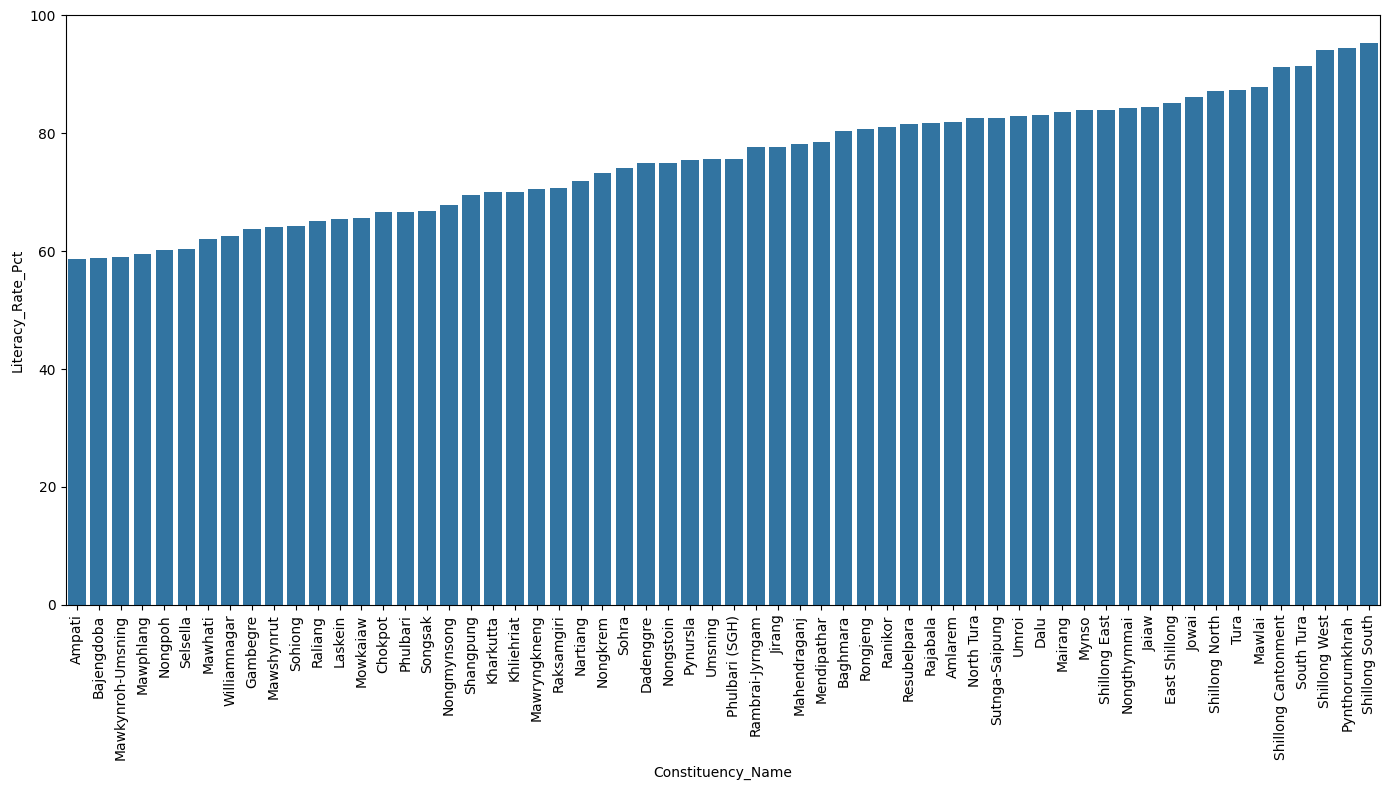

In [52]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=df.sort_values('Literacy_Rate_Pct'),
    x='Constituency_Name',
    y='Literacy_Rate_Pct'
)

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "Constituency_Plots/01_Literacy_Rate.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

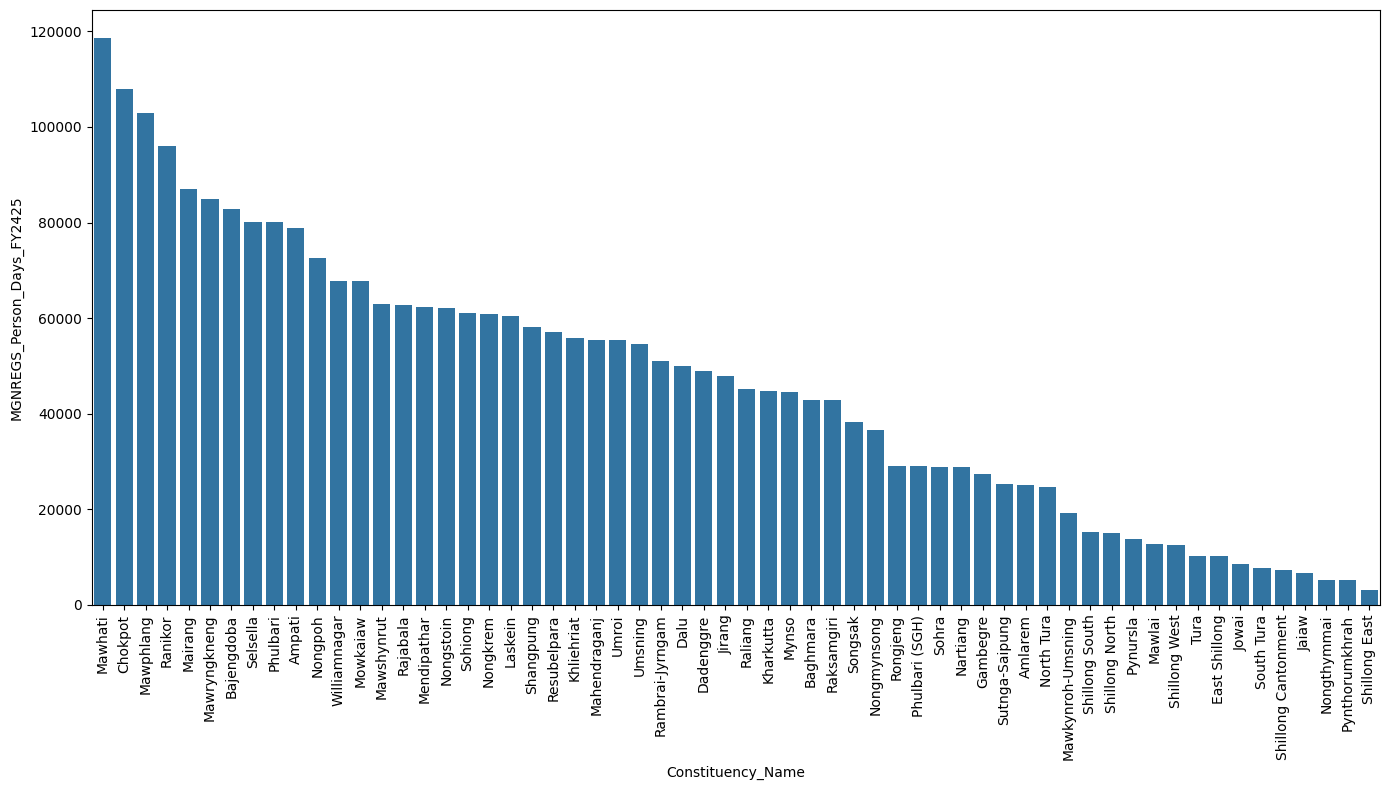

In [53]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=df.sort_values(
        'MGNREGS_Person_Days_FY2425',
        ascending=False
    ),
    x='Constituency_Name',
    y='MGNREGS_Person_Days_FY2425'
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "Constituency_Plots/02_MGNREGS.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

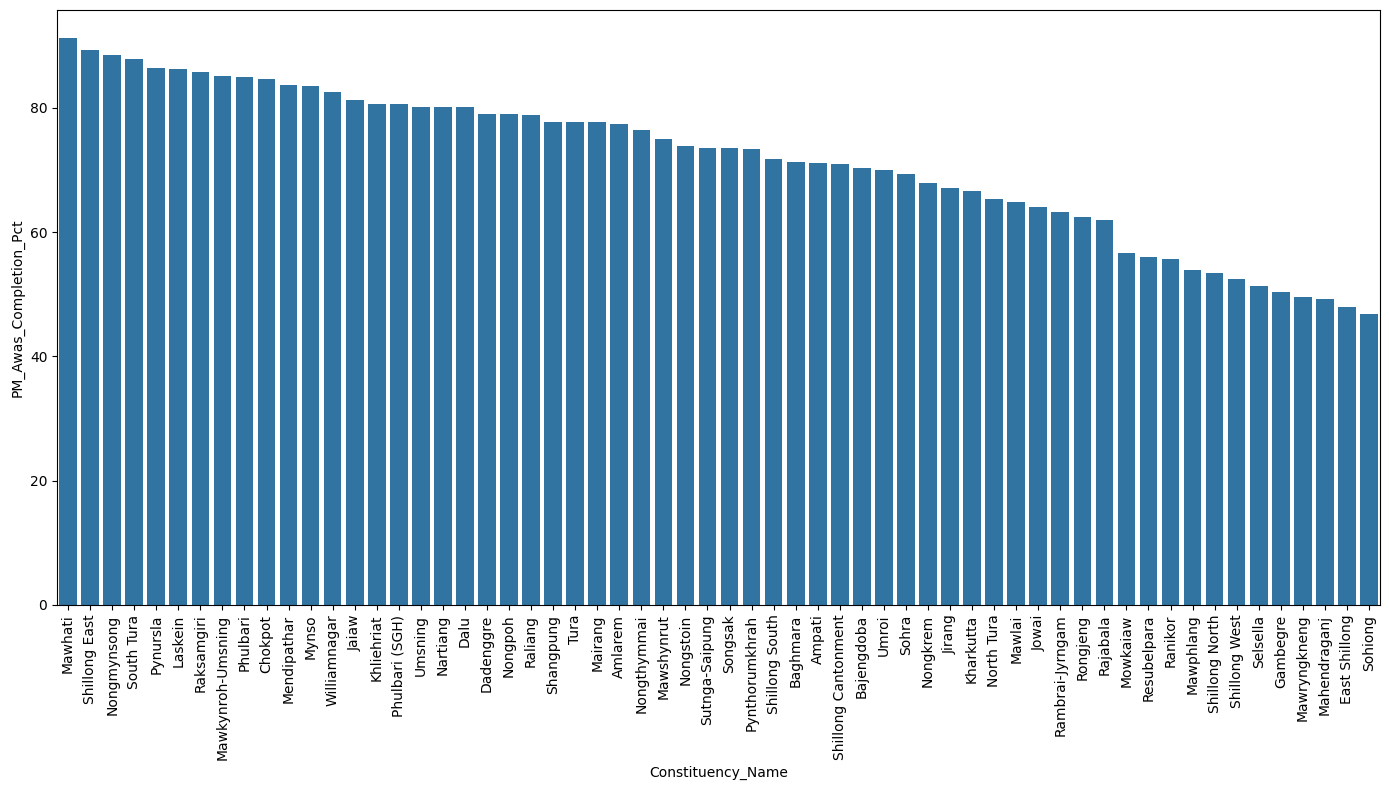

In [54]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=df.sort_values(
        'PM_Awas_Completion_Pct',
        ascending=False
    ),
    x='Constituency_Name',
    y='PM_Awas_Completion_Pct'
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "Constituency_Plots/03_PM_Awas.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

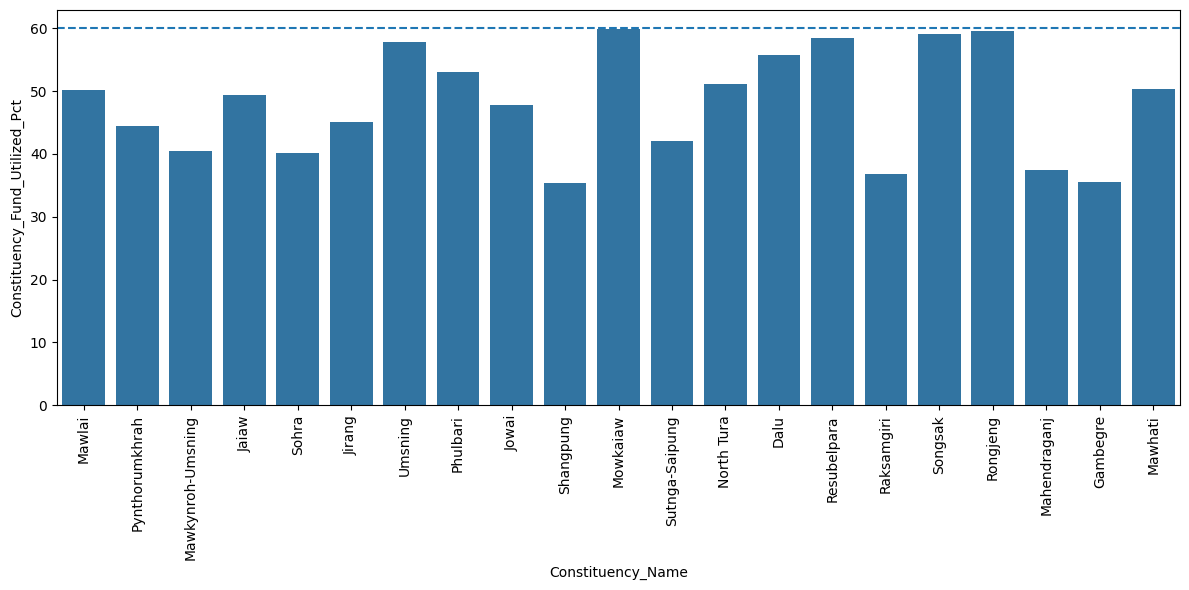

In [56]:
risk = df[
    df['Constituency_Fund_Utilized_Pct'] < 60
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=risk,
    x='Constituency_Name',
    y='Constituency_Fund_Utilized_Pct'
)

plt.axhline(60, linestyle='--')

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "Constituency_Plots/05_Fund_Risk.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

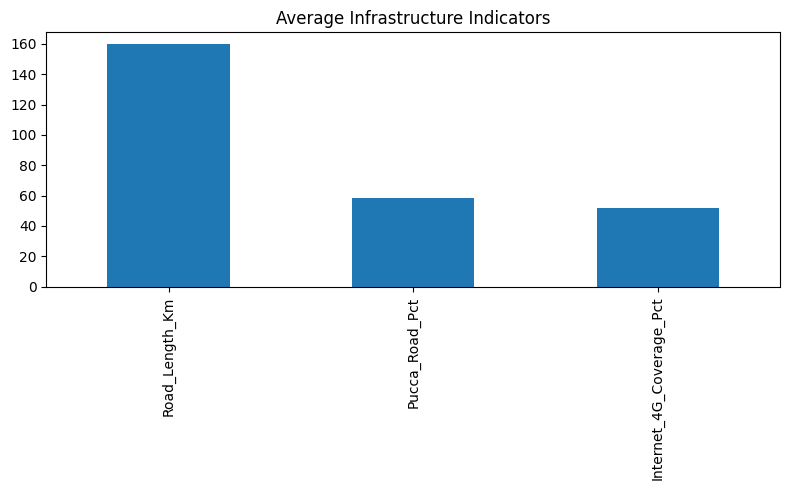

In [57]:
infra = df[[
    'Road_Length_Km',
    'Pucca_Road_Pct',
    'Internet_4G_Coverage_Pct'
]]

infra.mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Infrastructure Indicators")

plt.tight_layout()

plt.savefig(
    "Constituency_Plots/06_Infrastructure_Dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

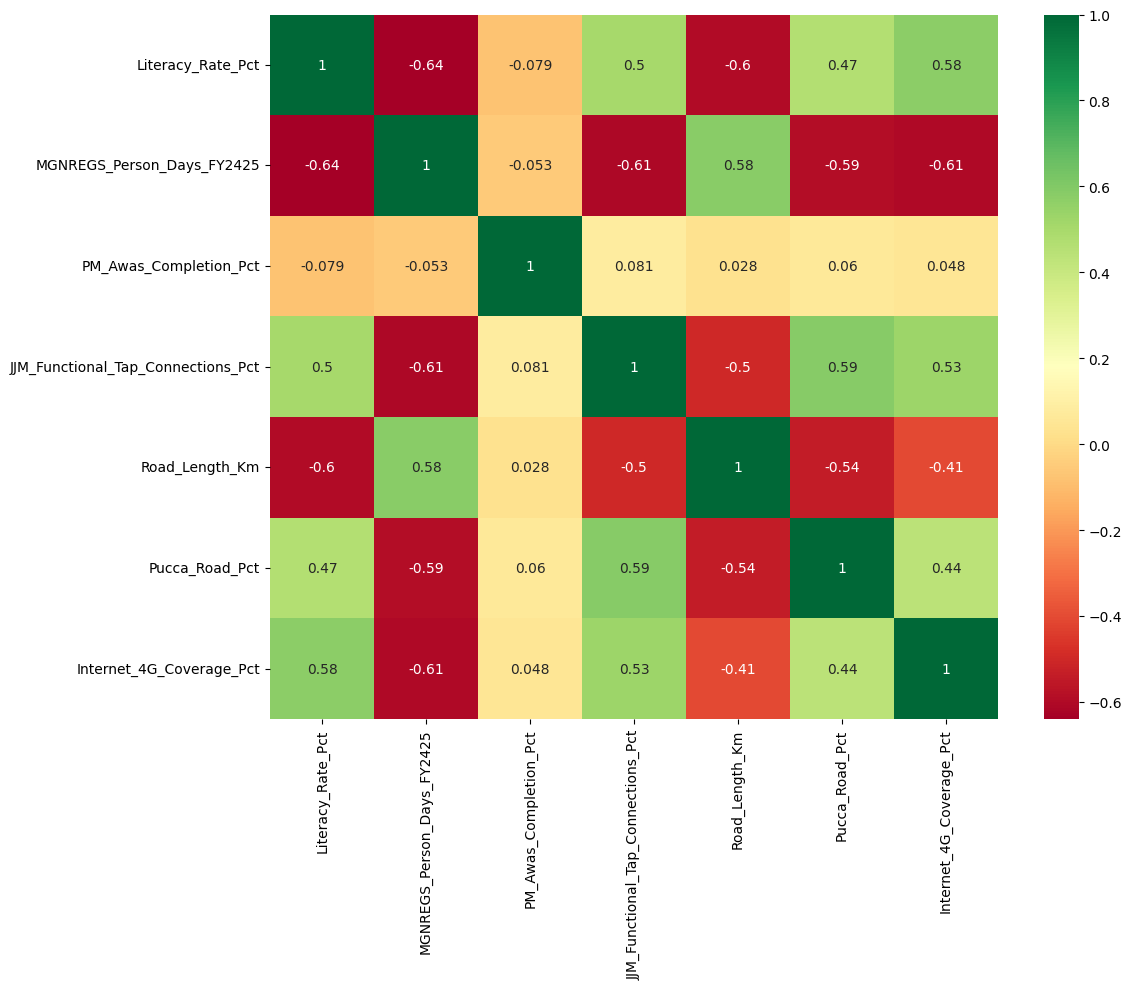

In [58]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df[[
        'Literacy_Rate_Pct',
        'MGNREGS_Person_Days_FY2425',
        'PM_Awas_Completion_Pct',
        'JJM_Functional_Tap_Connections_Pct',
        'Road_Length_Km',
        'Pucca_Road_Pct',
        'Internet_4G_Coverage_Pct'
    ]].corr(),
    annot=True,
    cmap='RdYlGn'
)

plt.tight_layout()

plt.savefig(
    "Constituency_Plots/07_Heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [59]:
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages(
    "Meghalaya_Constituency_Visual_Report.pdf"
)

for fig_num in plt.get_fignums():

    pdf.savefig(
        plt.figure(fig_num)
    )

pdf.close()

In [64]:
import os

In [65]:
print(os.getcwd())

C:\Users\ohabi


In [72]:
import os

In [73]:
folders = [
    "data",
    "src",
    "notebooks",
    "reports",
    "charts",
    "dashboard"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created!")

Project structure created!
